In [1]:
import pandas as pd

data = pd.read_csv("energydata_complete.csv")

print(data.head())
print(data.shape)

                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspeed  Visibility

In [3]:
#Now we extracted hour feature.
data["date"] = pd.to_datetime(data["date"])
data["hour"] = data["date"].dt.hour
print(data.head())


                 date  Appliances  lights     T1       RH_1    T2       RH_2  \
0 2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1 2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2 2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3 2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4 2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...   RH_9     T_out  Press_mm_hg  RH_out  \
0  19.79  44.730000  19.000000  ...  45.53  6.600000        733.5    92.0   
1  19.79  44.790000  19.000000  ...  45.56  6.483333        733.6    92.0   
2  19.79  44.933333  18.926667  ...  45.50  6.366667        733.7    92.0   
3  19.79  45.000000  18.890000  ...  45.40  6.250000        733.8    92.0   
4  19.79  45.000000  18.890000  ...  45.40  6.133333        733.9    92.0   

   Windspeed  Visibility  Tdewpoint        rv1        rv

In [8]:
features = [
"T1","RH_1",
"T2","RH_2",
"T6","RH_6",
"T_out",
"RH_out",
"Windspeed",
"Visibility",
"hour"
]

X = data[features]
y = data["Appliances"]
print(X.head())
print(y.head())

      T1       RH_1    T2       RH_2        T6       RH_6     T_out  RH_out  \
0  19.89  47.596667  19.2  44.790000  7.026667  84.256667  6.600000    92.0   
1  19.89  46.693333  19.2  44.722500  6.833333  84.063333  6.483333    92.0   
2  19.89  46.300000  19.2  44.626667  6.560000  83.156667  6.366667    92.0   
3  19.89  46.066667  19.2  44.590000  6.433333  83.423333  6.250000    92.0   
4  19.89  46.333333  19.2  44.530000  6.366667  84.893333  6.133333    92.0   

   Windspeed  Visibility  hour  
0   7.000000   63.000000    17  
1   6.666667   59.166667    17  
2   6.333333   55.333333    17  
3   6.000000   51.500000    17  
4   5.666667   47.666667    17  
0    60
1    60
2    50
3    50
4    60
Name: Appliances, dtype: int64


In [9]:
print(data.columns)

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'hour'],
      dtype='object')


In [10]:
data.columns.tolist()

['date',
 'Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'rv1',
 'rv2',
 'hour']

In [11]:
X = data[features]
y = data["Appliances"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train, y_train)

RandomForestRegressor()

In [14]:
predictions = model.predict(X_test)

print(predictions[:10])

[ 53.6 104.4  44.9  64.8  76.6 125.7 100.8  85.1  52.6  90.5]


In [15]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 30.756371928046615


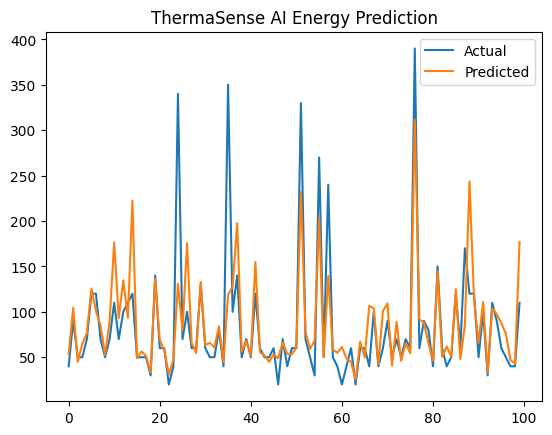

In [16]:
import matplotlib.pyplot as plt

plt.plot(y_test.values[:100], label="Actual")
plt.plot(predictions[:100], label="Predicted")
plt.legend()
plt.title("ThermaSense AI Energy Prediction")
plt.show()

In [17]:
importances = model.feature_importances_

for feature,importance in zip(features,importances):
    print(feature, importance)

T1 0.08701705459735662
RH_1 0.09955335653601813
T2 0.07793049820259078
RH_2 0.10780247061368727
T6 0.07535671694423776
RH_6 0.09066054388670372
T_out 0.09111564692058938
RH_out 0.07931998243237685
Windspeed 0.06502617741365159
Visibility 0.05303495196613597
hour 0.17318260048665188


In [18]:
for i in range(10):
    print("Actual:", y_test.iloc[i], "Predicted:", predictions[i])

Actual: 40 Predicted: 53.6
Actual: 90 Predicted: 104.4
Actual: 50 Predicted: 44.9
Actual: 50 Predicted: 64.8
Actual: 70 Predicted: 76.6
Actual: 120 Predicted: 125.7
Actual: 120 Predicted: 100.8
Actual: 70 Predicted: 85.1
Actual: 50 Predicted: 52.6
Actual: 70 Predicted: 90.5
